In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler


INPUT_PATH = "../data/bpm_25/8fts_3miners_ind_ilp_sm1_benchmark.csv"
INPUT_PATH = "../data/bpm_25/8fts_3miners_ind_ilp_sm1_shapley.csv"

METRIC_ORDER = ["fitness", "precision", "fscore","cfc", "size", "exectime"]

In [2]:
data = pd.read_csv(INPUT_PATH)
#features = pd.read_csv("../data/bpm_25/8fts_genEL_features.csv")
shapley = data.copy()[:5]
shapley

,algorithm,metric,feature_name,feature_value,shapley_value
0,inductive,benchtime,aq1,6413,3.458333
1,inductive,benchtime,svo,758,2.273333
2,inductive,benchtime,tlv,2776,16.348333
3,inductive,benchtime,aq1,6413,-46.155000
4,inductive,benchtime,svo,758,-42.620000


In [3]:
INPUT_PATH = "../data/bpm_25/8fts_3miners_ind_ilp_sm1_benchmark.csv"
FEATURE_PATH = "../data/bpm_25/8fts_genEL_features.csv"

METRIC_ORDER = ["fitness", "precision", "fscore","cfc", "size", "exectime"]
data = pd.read_csv(INPUT_PATH)
feat = pd.read_csv(FEATURE_PATH)
#features = pd.read_csv("../data/bpm_25/8fts_genEL_features.csv")
benchmark = data.copy()
feat = feat.copy()
print(benchmark.columns)
print(feat.columns)
#print(benchmark[benchmark['log']=='genEL10000_6413_nan_nan_nan_758_31382_nan_nan'])
#print(feat[feat['log']=='genEL10000_6413_nan_nan_nan_758_31382_nan_nan'])


Index(['log', 'benchtime_inductive', 'cfc_inductive', 'exectime_inductive',
       'fitness_inductive', 'fscore_inductive', 'pnsize_inductive',
       'precision_inductive', 'size_inductive', 'fitness_sm1', 'precision_sm1',
       'fscore_sm1', 'size_sm1', 'cfc_sm1', 'pnsize_sm1', 'exectime_sm1',
       'benchtime_sm1', 'benchtime_ilp', 'cfc_ilp', 'exectime_ilp',
       'fitness_ilp', 'fscore_ilp', 'pnsize_ilp', 'precision_ilp', 'size_ilp'],
      dtype='object')
Index(['activities_q1', 'eventropy_k_block_ratio_3', 'log',
       'n_unique_start_activities', 'ratio_top_5_variants',
       'skewness_variant_occurrence', 'start_activities_q1',
       'target_similarity', 'trace_len_kurtosis_hist', 'trace_len_variance'],
      dtype='object')


In [4]:
feat_bench = feat.merge(benchmark, how='inner')

In [5]:
INPUT_PATH = "../../gedi/data/BaselineED_bench.csv"
FEATURE_PATH = "../../gedi/data/BaselineED_feat.csv"
FEATURE_PATH = "../data/bpm_25/bpic_features_p.csv"

benchmark = pd.read_csv(INPUT_PATH)
feat = pd.read_csv(FEATURE_PATH)
print(benchmark.columns)
print(feat.columns)
#feat.rename(columns={'ratio_unique_traces_per_trace': 'ratio_variants_per_number_of_traces'}, inplace=True)
#feat[['log', 'ratio_variants_per_number_of_traces','ratio_most_common_variant','ratio_top_10_variants']].head()
feat_bench = feat.merge(benchmark, how='inner')
#feat_bench

Index(['log', 'fitness_ilp', 'precision_ilp', 'fscore_ilp', 'size_ilp',
       'pnsize_ilp', 'cfc_ilp', 'fitness_imf', 'precision_imf', 'fscore_imf',
       'size_imf', 'pnsize_imf', 'cfc_imf', 'fitness_heu', 'precision_heu',
       'fscore_heu', 'size_heu', 'pnsize_heu', 'cfc_heu'],
      dtype='object')
Index(['log', 'n_traces', 'n_unique_traces', 'ratio_unique_traces_per_trace',
       'trace_len_min', 'trace_len_max', 'trace_len_mean', 'trace_len_median',
       'trace_len_mode', 'trace_len_std',
       ...
       'entropy_knn_5', 'entropy_knn_7', 'variant_entropy',
       'normalized_variant_entropy', 'sequence_entropy',
       'normalized_sequence_entropy', 'sequence_entropy_linear_forgetting',
       'normalized_sequence_entropy_linear_forgetting',
       'sequence_entropy_exponential_forgetting',
       'normalized_sequence_entropy_exponential_forgetting'],
      dtype='object', length=101)


In [6]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

print(feat.columns)
feature_names = [item for item in feat.columns if 'log' not in item]
feature_names = [item for item in feature_names if 'target_similarity' not in item]
feature_names = ['trace_len_mean','n_unique_activities','activities_q1', 'entropy_k_block_ratio_3',
       'n_unique_start_activities', 'ratio_top_5_variants',
       'skewness_variant_occurrence', 'start_activities_q1',
       'trace_len_kurtosis_hist', 'trace_len_variance']
feature_names = ['trace_len_mean', 'n_unique_activities']
metric_names = ['benchtime_inductive', 'cfc_inductive', 'exectime_inductive',
       'fitness_inductive', 'fscore_inductive', 'pnsize_inductive',
       'precision_inductive', 'size_inductive', 'fitness_sm1', 'precision_sm1',
       'fscore_sm1', 'size_sm1', 'cfc_sm1', 'pnsize_sm1', 'exectime_sm1',
       'benchtime_sm1', 'benchtime_ilp', 'cfc_ilp', 'exectime_ilp',
       'fitness_ilp', 'fscore_ilp', 'pnsize_ilp', 'precision_ilp', 'size_ilp']
metric_names = [item for item in benchmark.columns if 'log' not in item]

#scaler = StandardScaler()
#feat_bench[feature_names] = scaler.fit_transform(feat_bench[feature_names])
feat_bench.columns

Index(['log', 'n_traces', 'n_unique_traces', 'ratio_unique_traces_per_trace',
       'trace_len_min', 'trace_len_max', 'trace_len_mean', 'trace_len_median',
       'trace_len_mode', 'trace_len_std',
       ...
       'entropy_knn_5', 'entropy_knn_7', 'variant_entropy',
       'normalized_variant_entropy', 'sequence_entropy',
       'normalized_sequence_entropy', 'sequence_entropy_linear_forgetting',
       'normalized_sequence_entropy_linear_forgetting',
       'sequence_entropy_exponential_forgetting',
       'normalized_sequence_entropy_exponential_forgetting'],
      dtype='object', length=101)


Index(['log', 'n_traces', 'n_unique_traces', 'ratio_unique_traces_per_trace',
       'trace_len_min', 'trace_len_max', 'trace_len_mean', 'trace_len_median',
       'trace_len_mode', 'trace_len_std',
       ...
       'fscore_imf', 'size_imf', 'pnsize_imf', 'cfc_imf', 'fitness_heu',
       'precision_heu', 'fscore_heu', 'size_heu', 'pnsize_heu', 'cfc_heu'],
      dtype='object', length=119)

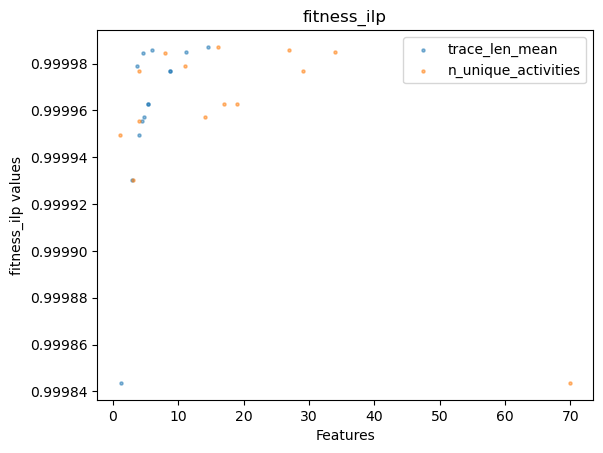

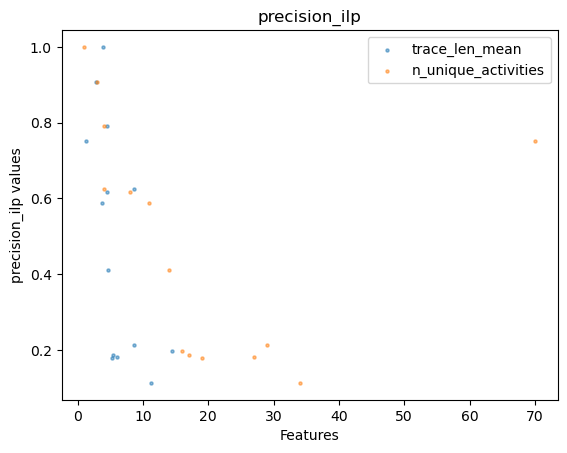

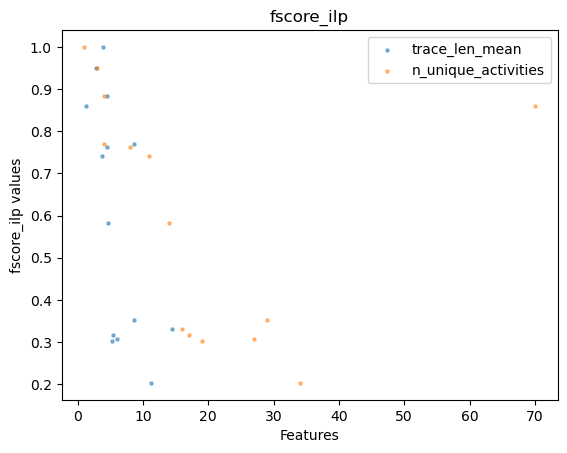

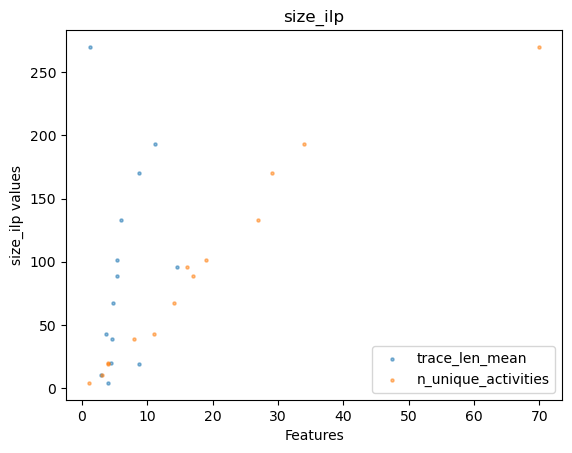

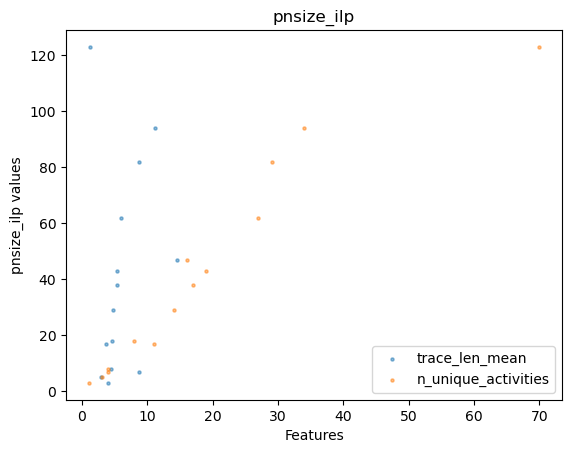

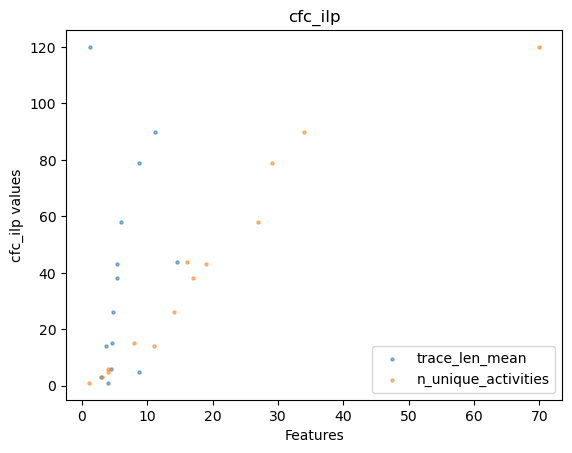

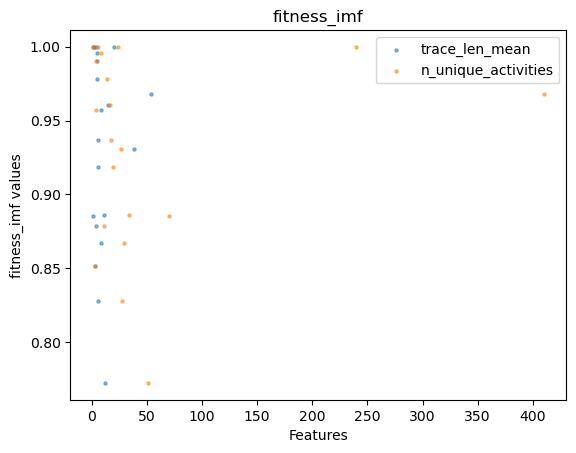

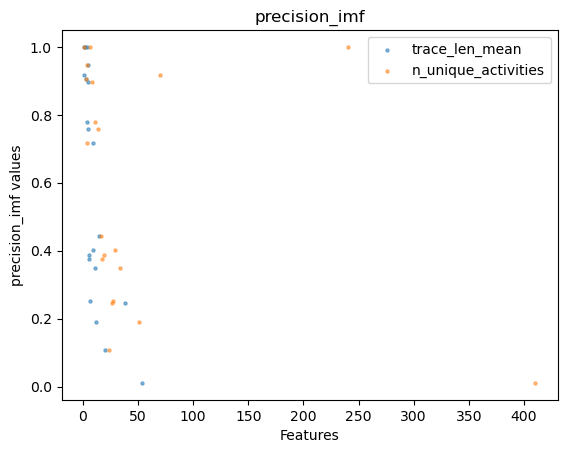

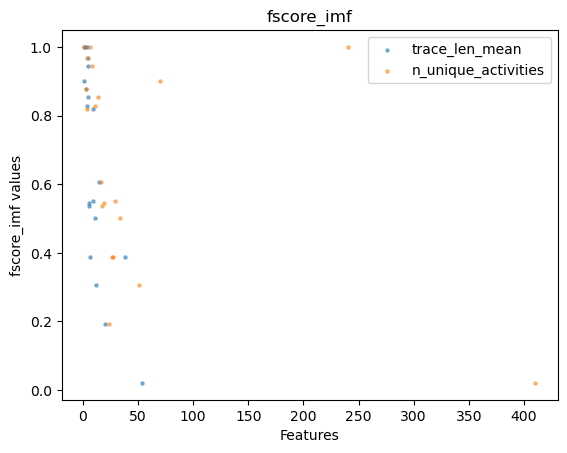

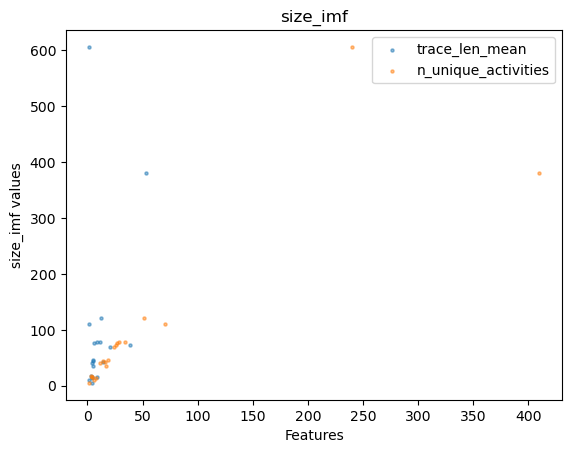

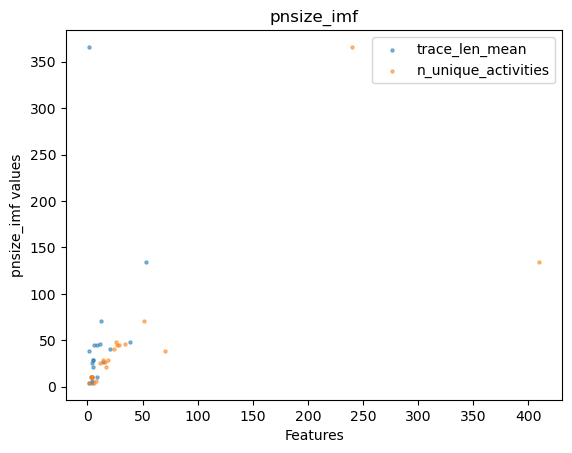

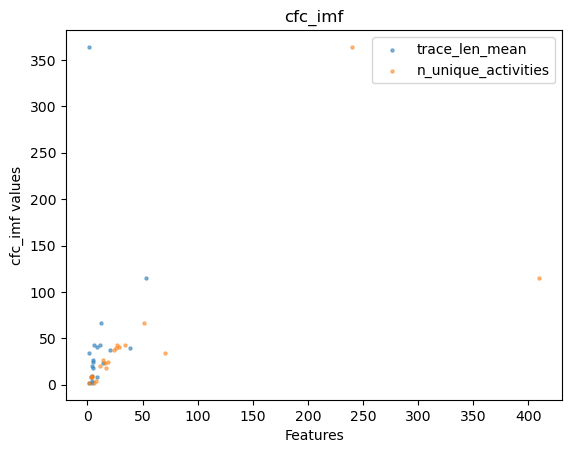

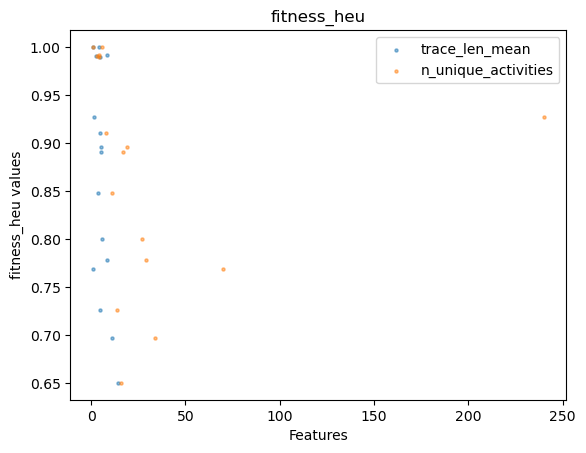

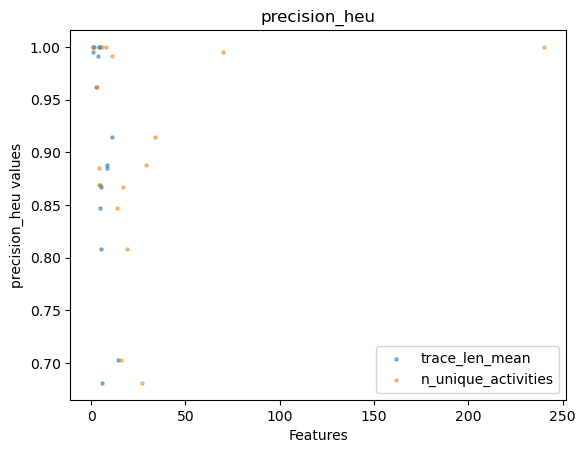

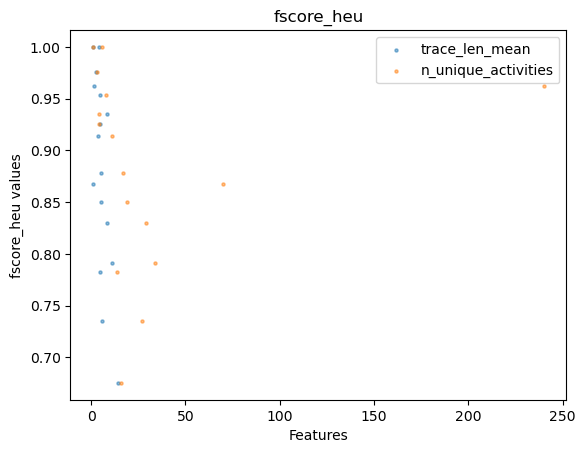

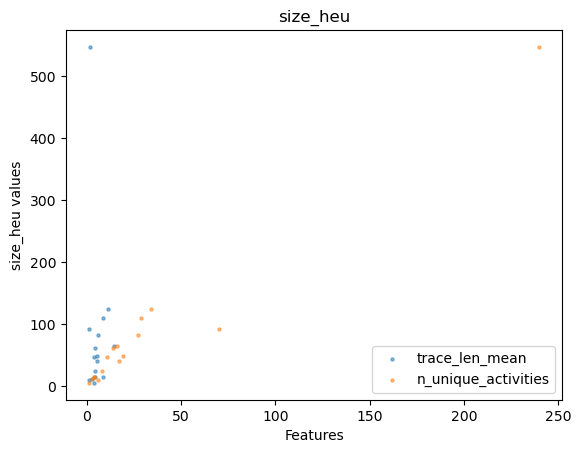

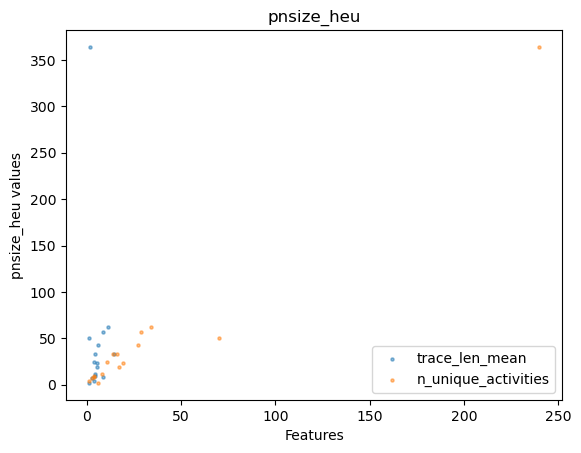

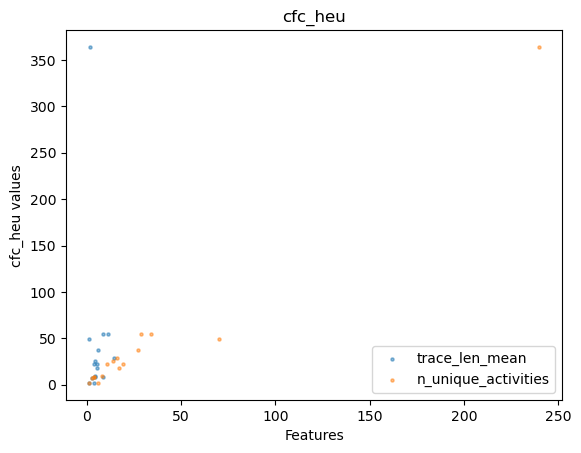

In [7]:
for metric_name in metric_names:
    for feature_name in feature_names:
        plt.scatter(feat_bench[feature_name], feat_bench[metric_name], label=feature_name, 
                    alpha=0.5, s=5)

    plt.xlabel('Features')
    plt.ylabel(metric_name+ ' values')
    plt.legend()
    plt.title(metric_name)
    plt.show()

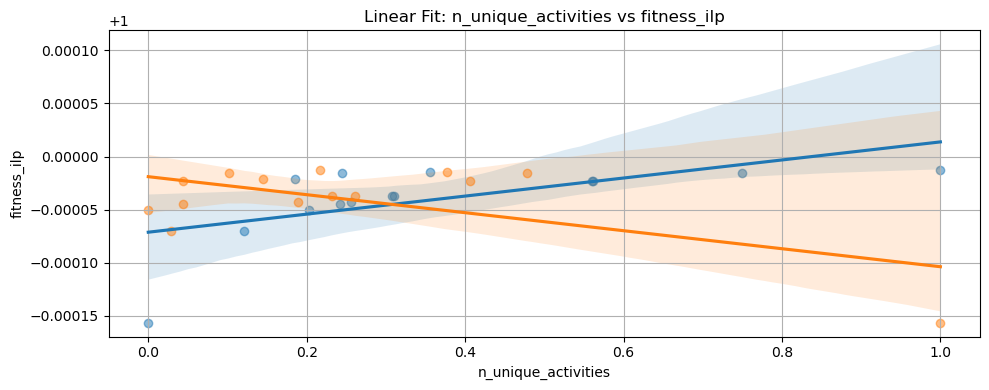

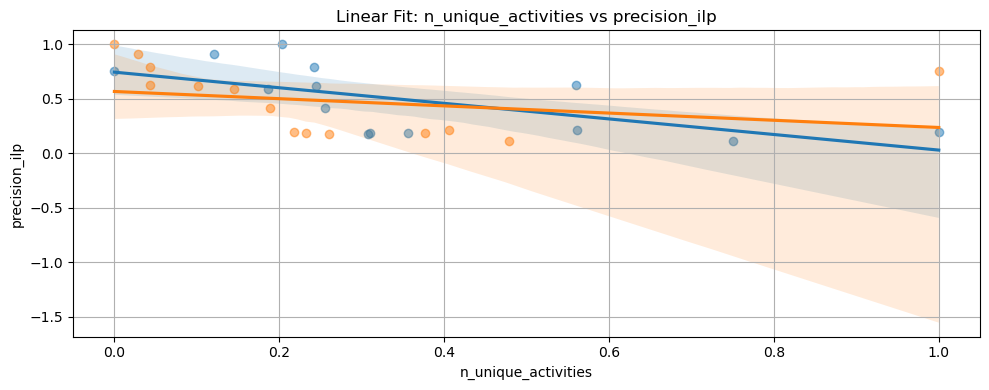

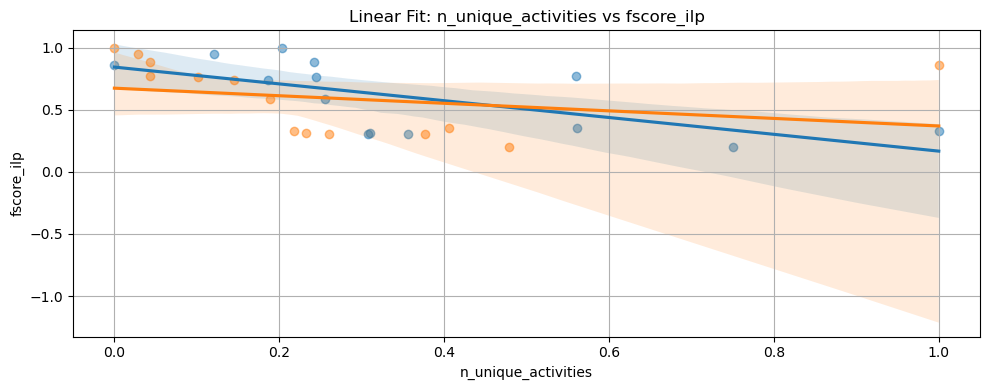

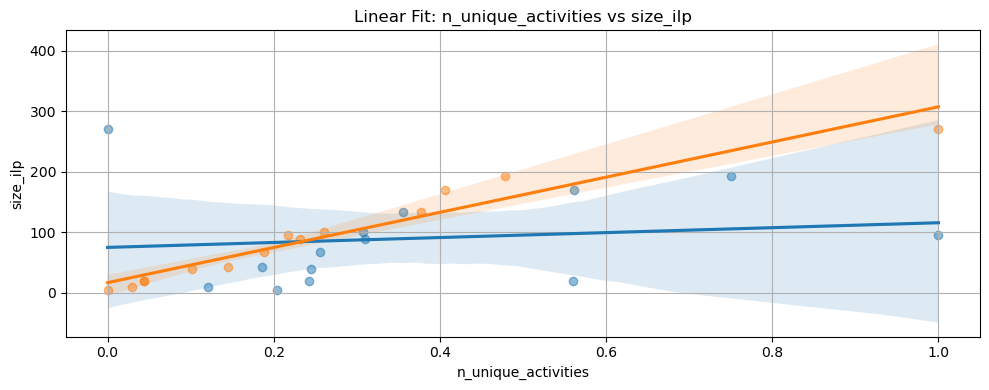

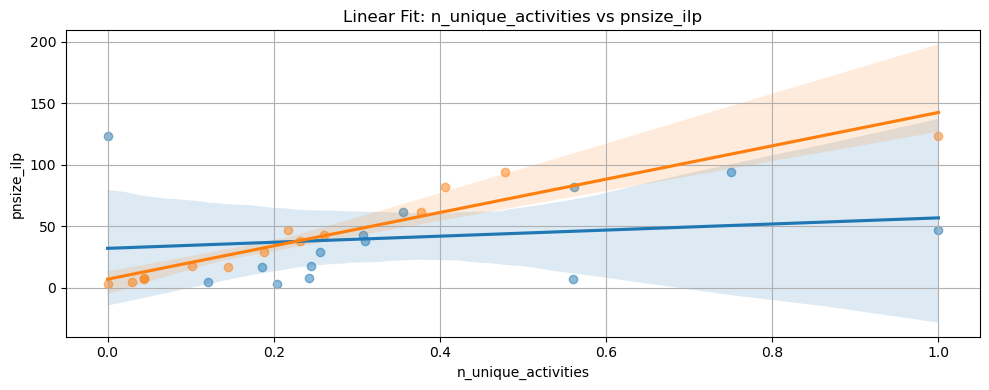

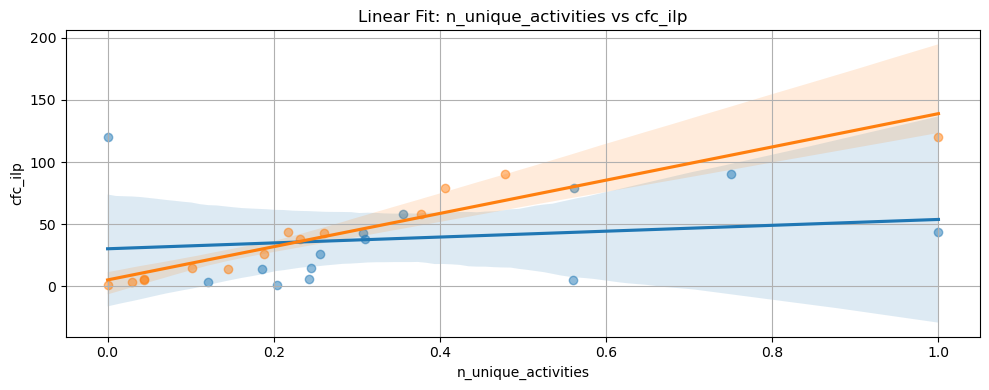

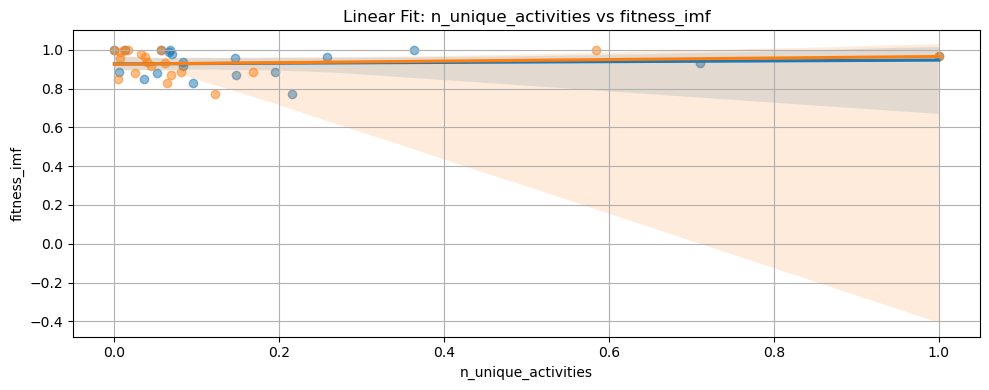

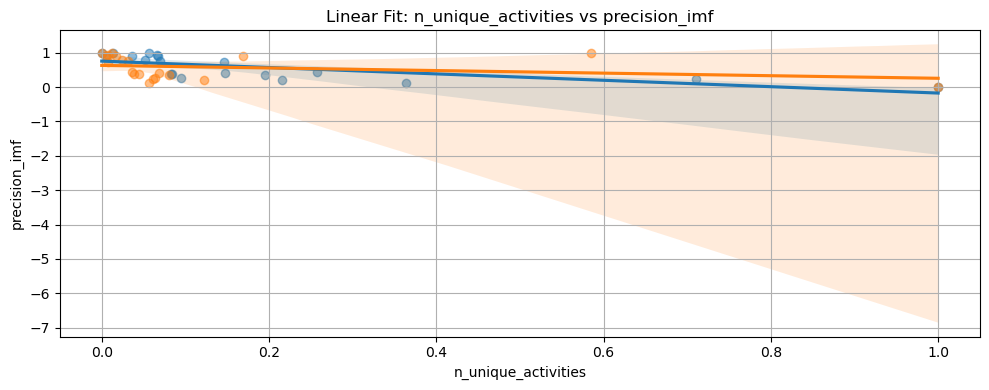

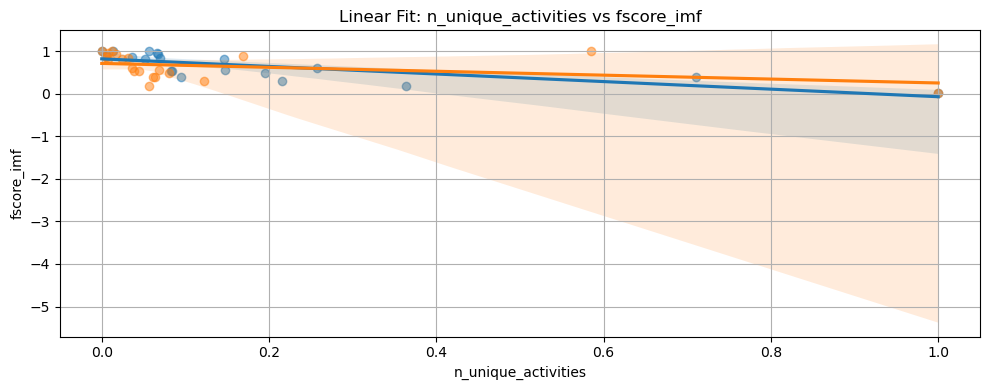

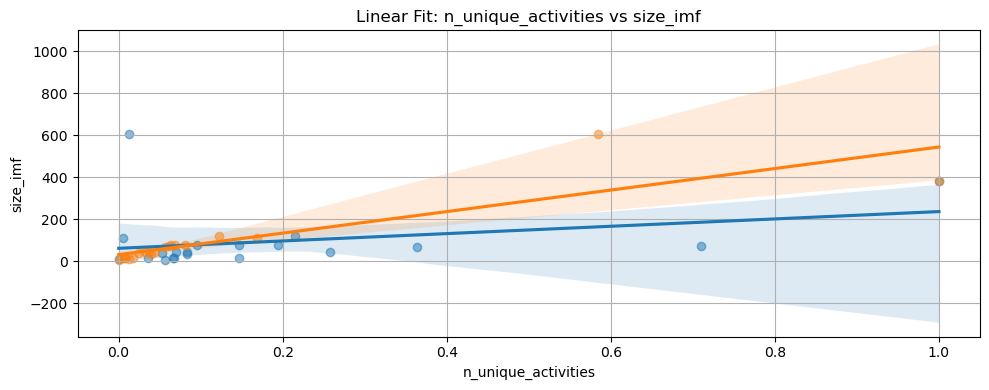

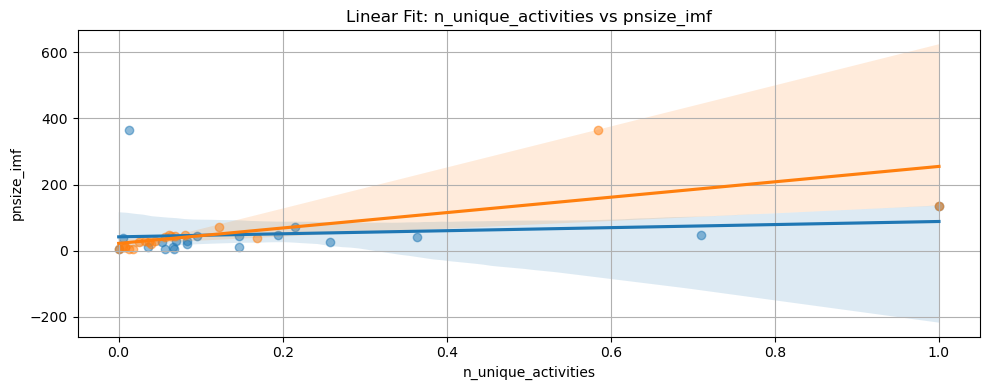

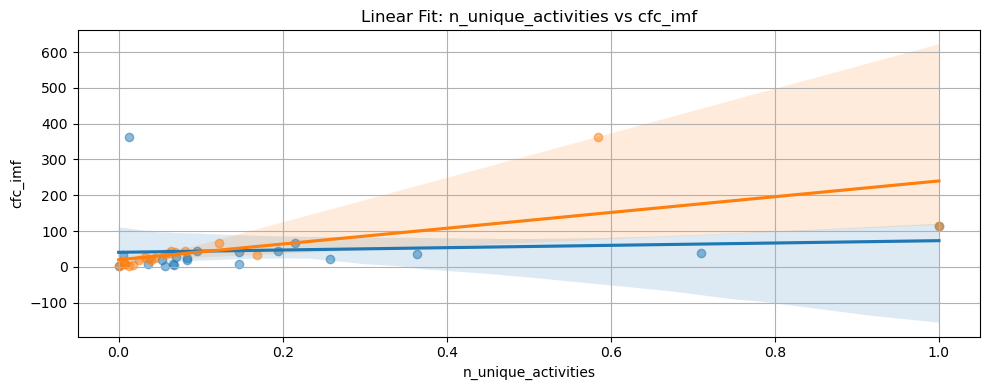

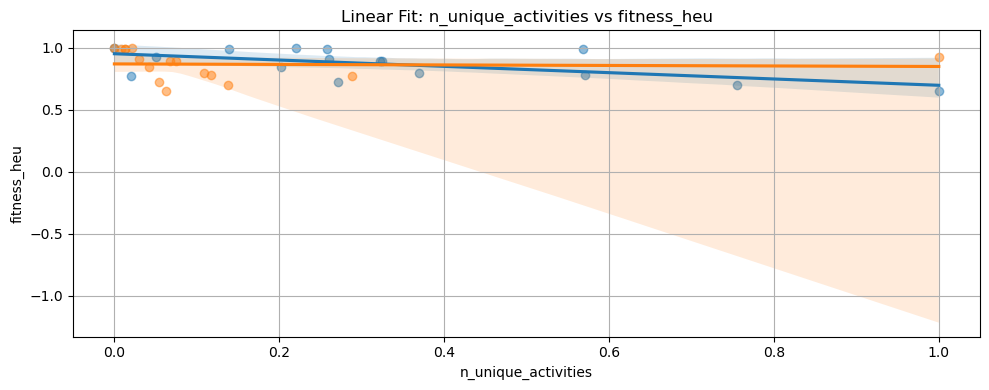

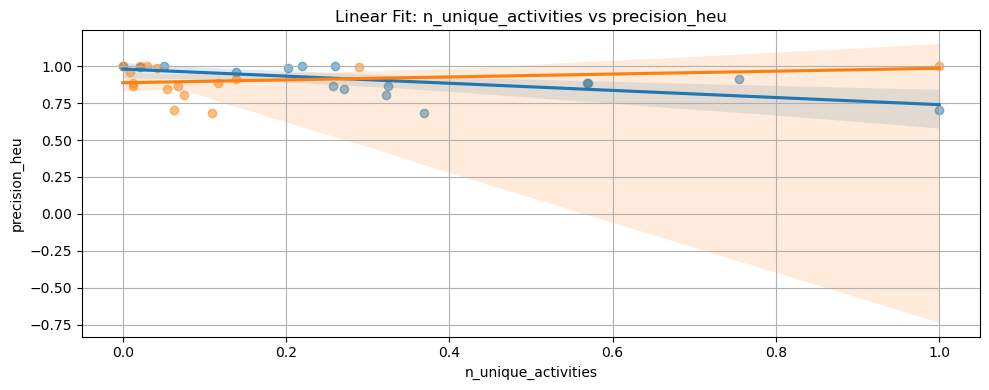

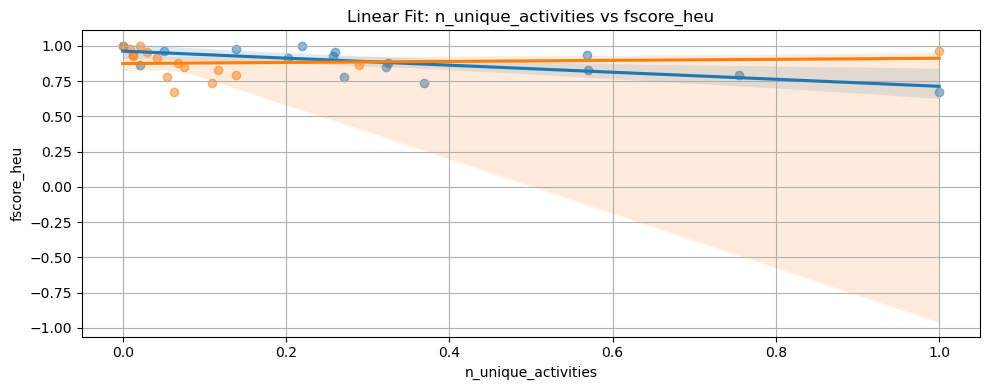

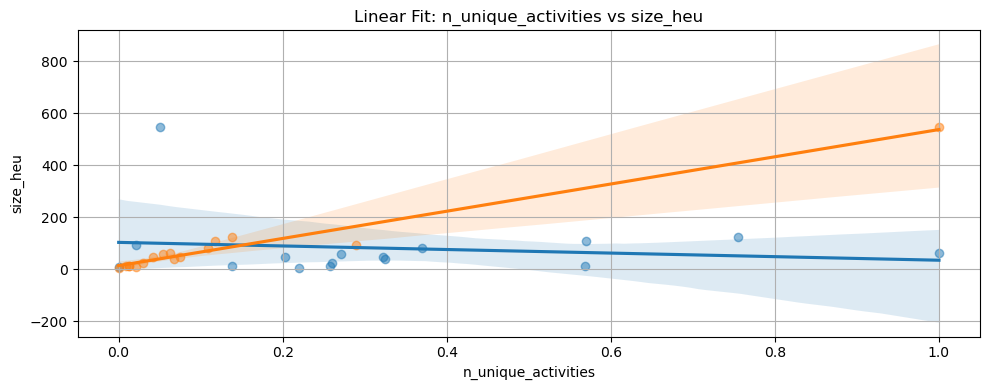

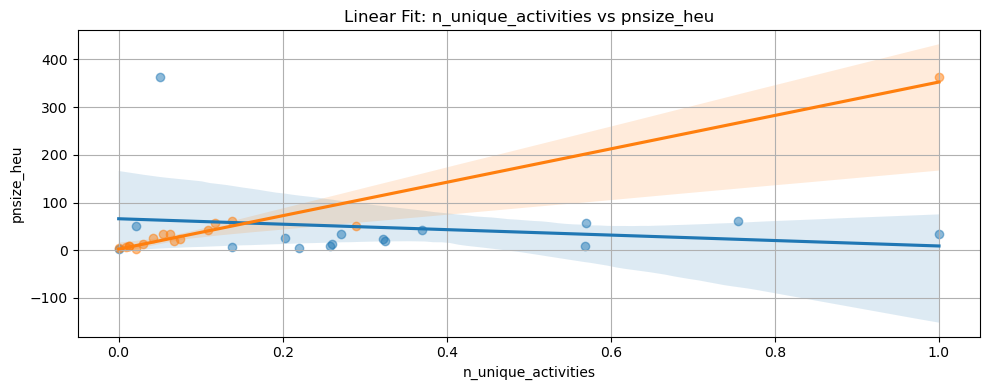

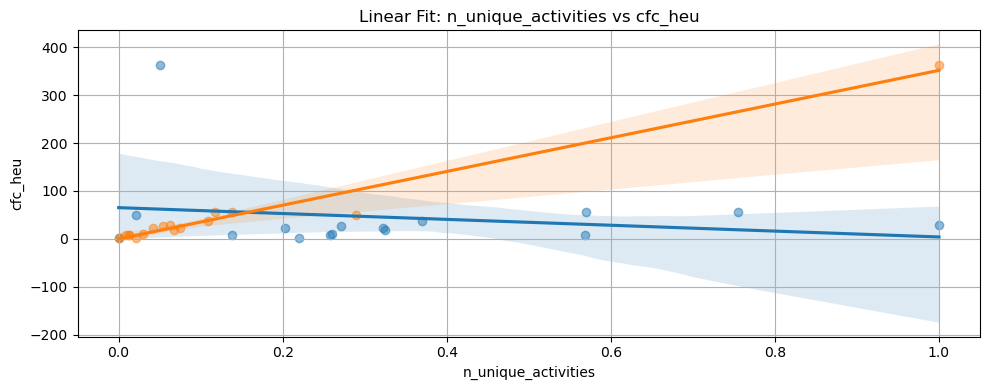

In [29]:
import seaborn as sns

for metric in metric_names:
    fig, ax = plt.subplots(figsize=(10,4))
    for feature in feature_names:
        scaler = MinMaxScaler()
        feat_bench_clean = feat_bench.dropna(subset=feature_names + [metric])

        X_scaled = scaler.fit_transform(feat_bench_clean[feature_names])
        feat_scaled = pd.DataFrame(X_scaled, columns=feature_names)
        feat_scaled[metric] = feat_bench_clean[metric].values
        
        sns.regplot(x=feat_scaled[feature], y=feat_scaled[metric], scatter_kws={'alpha': 0.5},
                    ax=ax)
        
        #print(feat_bench_clean.columns)
        '''valid_mask = feat_bench_clean[feature].notna() & feat_bench_clean[metric].notna()
        x_valid = feat_bench_clean.loc[valid_mask, feature]
        y_valid = feat_bench_clean.loc[valid_mask, metric]
        
        for i in valid_mask[valid_mask].index:  # indices where valid_mask == True
            x_val = df.at[i, feature]
            y_val = df.at[i, metric]
            if np.isfinite(x_val) and np.isfinite(y_val):
                ax.text(
                    x_val,
                    y_val,
                    str(feat_bench_clean.at[i, 'log']),
                    fontsize=7,
                    alpha=0.7,
                    ha='left',
                    va='bottom'
                )'''
        
    plt.xlabel(feature)
    plt.ylabel(metric)
    plt.title(f'Linear Fit: {feature} vs {metric}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [19]:
scaler = MinMaxScaler()
feat_bench_clean = feat_bench.dropna(subset=feature_names + [metric])

X_scaled = scaler.fit_transform(feat_bench_clean[feature_names])
feat_scaled = pd.DataFrame(X_scaled, columns=feature_names)
feat_scaled[metric] = feat_bench_clean[metric].values

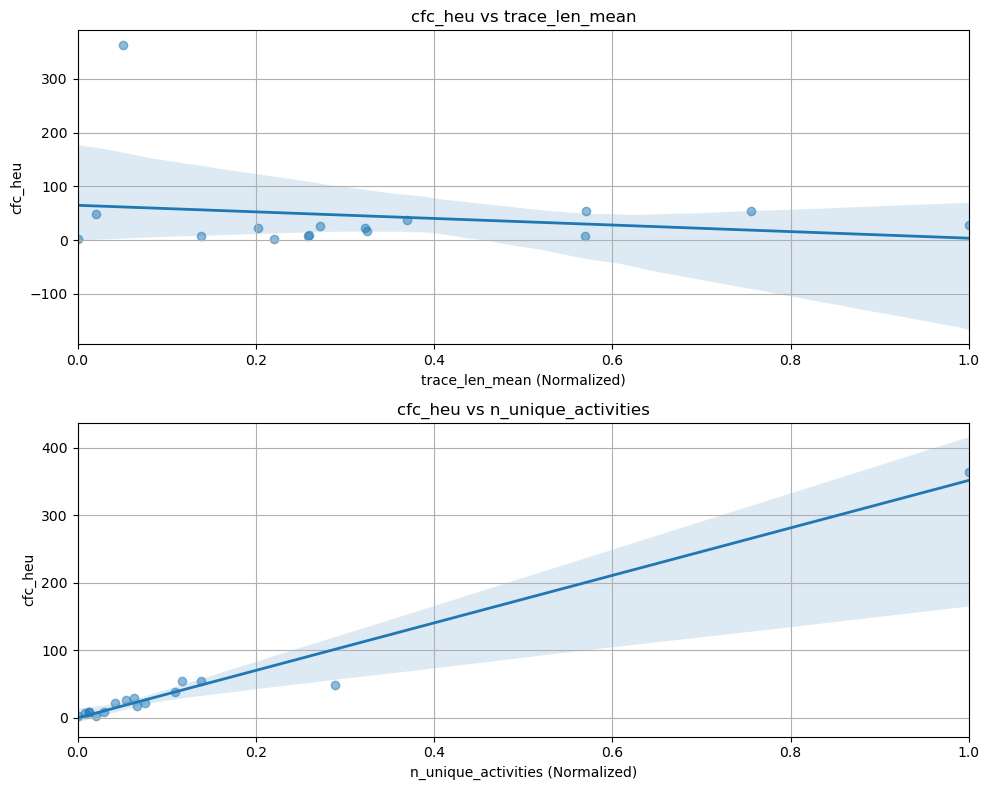

In [10]:
import numpy as np
df = feat_scaled.copy()
feature_names = ['trace_len_mean', 'n_unique_activities']

fig, axs = plt.subplots(len(feature_names), 1, figsize=(10, 4 * len(feature_names)))

for i, feature in enumerate(feature_names):
    ax = axs[i]
    sns.regplot(
        x=df[feature],
        y=df[metric],
        ax=ax,
        scatter_kws={'alpha': 0.5},
        line_kws={'linewidth': 2},
        label=feature
    )
    ax.set_xlabel(f'{feature} (Normalized)')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs {feature}')
    
    # Force x-axis limits from 0 to 1
    ax.set_xlim(0, 1)
    ax.grid(True)

plt.tight_layout()
plt.show()

Index(['trace_len_mean', 'n_unique_activities', 'cfc_heu'], dtype='object')


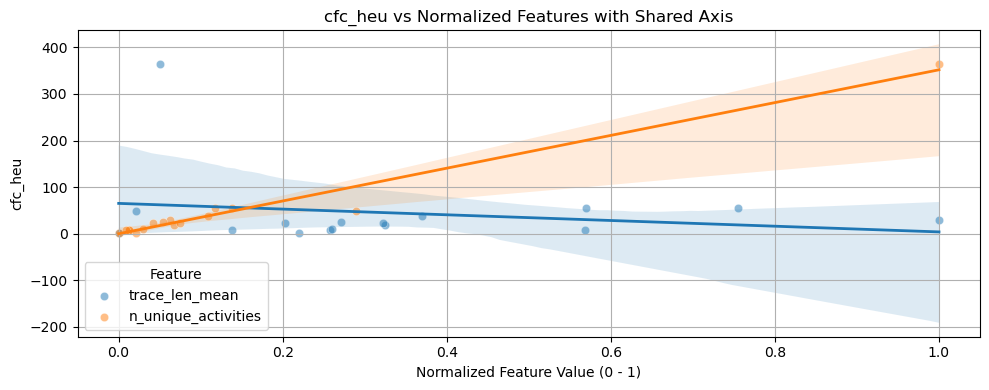

In [15]:
print(df.columns)
fig, ax = plt.subplots(figsize=(10,4))
colors = ['tab:blue', 'tab:orange']

# Plot both features on the normalized x-axis
for feature, color in zip(feature_names, colors):
    sns.scatterplot(
        x=df[feature],
        y=df[metric],
        ax=ax,
        alpha=0.5,
        label=feature,
        color=color
    )
    sns.regplot(
        x=df[feature],
        y=df[metric],
        scatter=False,
        ax=ax,
        color=color,
        line_kws={'linewidth': 2}
    )

#ax.set_xlim(0, 1)
ax.set_xlabel('Normalized Feature Value (0 - 1)')
ax.set_ylabel(metric)
ax.grid(True)


plt.title(f'{metric} vs Normalized Features with Shared Axis')
plt.legend(title='Feature')
plt.tight_layout()
plt.show()

['trace_len_mean', 'n_unique_activities'] cfc_heu Index(['trace_len_mean', 'n_unique_activities', 'cfc_heu'], dtype='object')
0.0 1.0
0.0 1.0


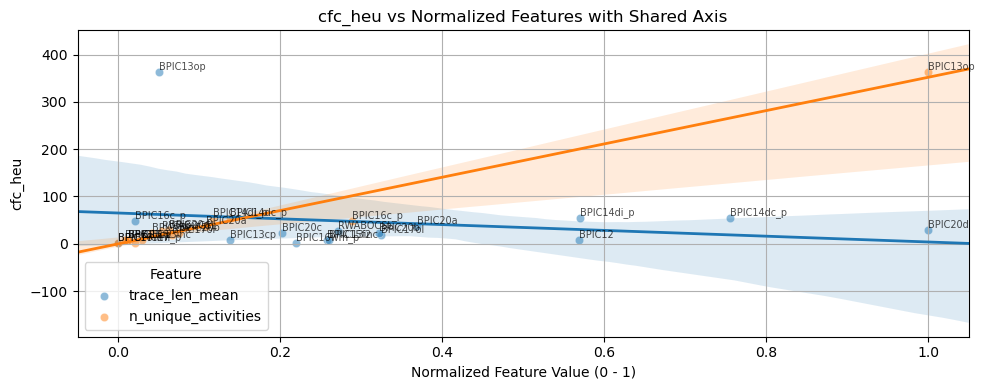

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_linreg_metric(df, feature_names, metric):

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.set_xlim(auto=True)
    ax.set_ylim(auto=True)

    colors = ['tab:blue', 'tab:orange']

    for feature, color in zip(feature_names, colors):
        print(df[feature].min(), df[feature].max())

        # Filter valid data (no NaNs)
        valid_mask = df[feature].notna() & df[metric].notna()
        x_valid = df.loc[valid_mask, feature]
        y_valid = df.loc[valid_mask, metric]

        # Scatter plot
        sns.scatterplot(
            x=x_valid,
            y=y_valid,
            ax=ax,
            alpha=0.5,
            label=feature,
            color=color
        )

        # Regression line without truncation on valid data
        sns.regplot(
            x=x_valid,
            y=y_valid,
            scatter=False,
            ax=ax,
            color=color,
            line_kws={'linewidth': 2},
            truncate=False
        )

        # Add labels only for points with finite coordinates
        for i in valid_mask[valid_mask].index:  # indices where valid_mask == True
            x_val = df.at[i, feature]
            y_val = df.at[i, metric]
            if np.isfinite(x_val) and np.isfinite(y_val):
                ax.text(
                    x_val,
                    y_val,
                    str(feat_bench.at[i, 'log']),
                    fontsize=7,
                    alpha=0.7,
                    ha='left',
                    va='bottom'
                )

    ax.set_xlabel('Normalized Feature Value (0 - 1)')
    ax.set_ylabel(metric)
    ax.grid(True)
    #ax.set_xlim(0, 1)

    plt.title(f'{metric} vs Normalized Features with Shared Axis')
    plt.legend(title='Feature')
    plt.tight_layout()
    plt.show()
    
print(feature_names, metric, df.columns)
plot_linreg_metric(df, feature_names, metric)

In [13]:
print(df[feature].min(), df[feature].max())

print(feat_bench[['log','trace_len_mean','n_unique_activities','cfc_heu']])
df[['trace_len_mean','n_unique_activities','cfc_heu']]

0.0 1.0
           log  trace_len_mean  n_unique_activities  cfc_heu
0    BPIC16c_p        1.278761                   70     49.0
1   BPIC16wm_p        3.966733                    1      2.0
2     BPIC15f2       53.310096                  410      NaN
3       BPIC12       20.035149                   24      NaN
4     BPIC13cp        4.478816                    4      8.0
5    BPIC13inc        8.675271                    4      8.0
6     BPIC13op        2.870574                    3      7.0
7       BPIC17       38.156305                   26      NaN
8     BPIC17ol        4.508641                    8      9.0
9   BPIC14dc_p        1.681944                  240    364.0
10  BPIC14di_p        1.000000                    6      2.0
11     BPIC20a        5.374952                   17     18.0
12     BPIC20b       11.187936                   34     55.0
13     BPIC20c       12.254919                   51      NaN
14     BPIC20d        8.692711                   29     55.0
15    RWABOCSL  

,trace_len_mean,n_unique_activities,cfc_heu
0,0.020665,0.288703,49.0
1,0.219929,0.000000,2.0
2,0.257890,0.012552,8.0
3,0.568980,0.012552,8.0
4,0.138669,0.008368,7.0
5,0.260101,0.029289,9.0
6,0.050554,1.000000,364.0
7,0.000000,0.020921,2.0
8,0.324322,0.066946,18.0
9,0.755248,0.138075,55.0


In [14]:
for feature in feature_names:
    print(f"{feature} min: {df[feature].min()}, max: {df[feature].max()}")
print(f"{metric} min: {df[metric].min()}, max: {df[metric].max()}")


trace_len_mean min: 0.0, max: 1.0
n_unique_activities min: 0.0, max: 1.0
cfc_heu min: 2.0, max: 364.0


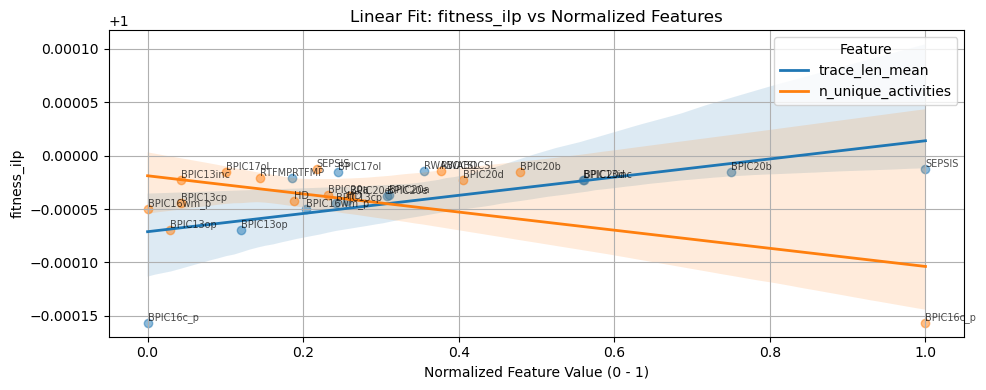

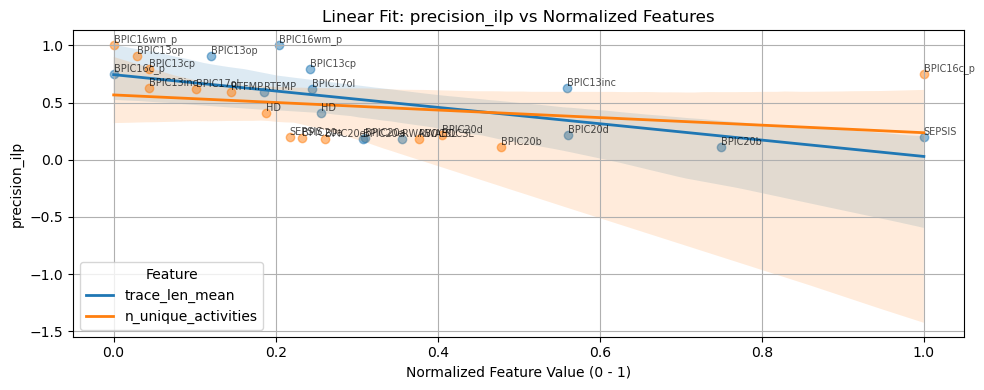

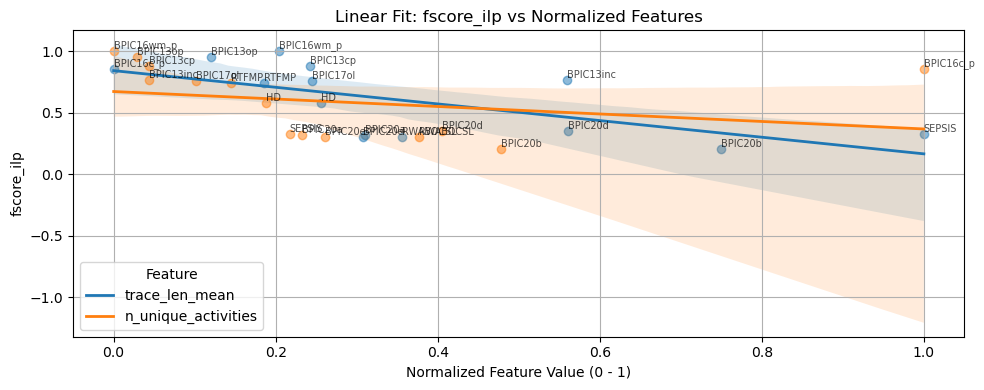

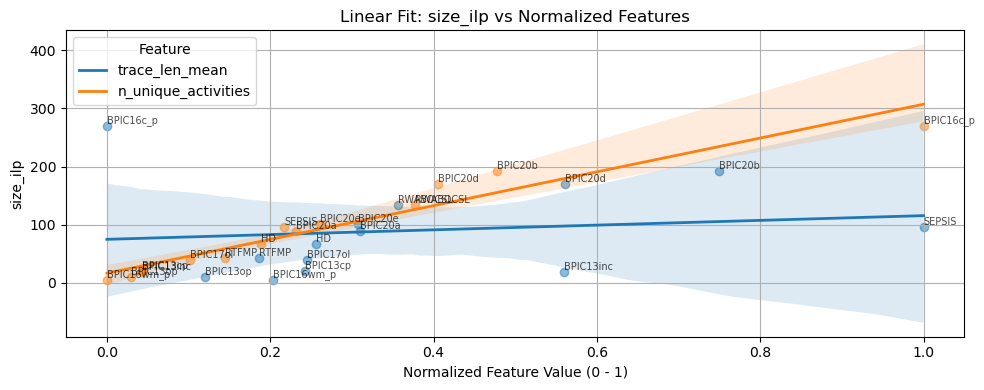

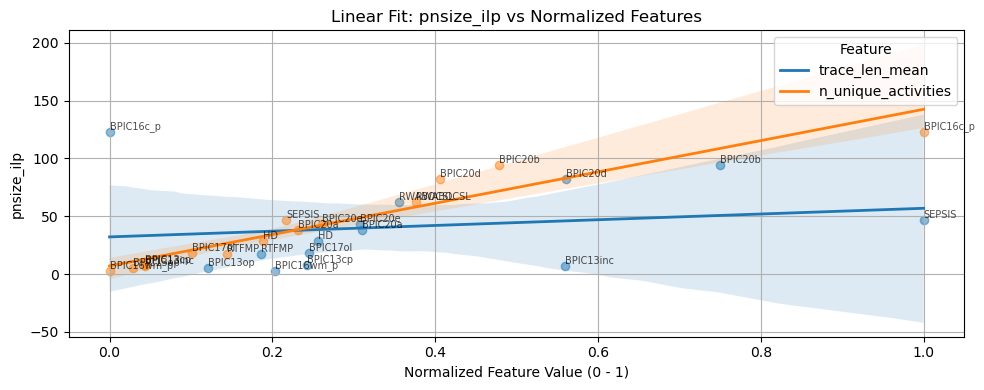

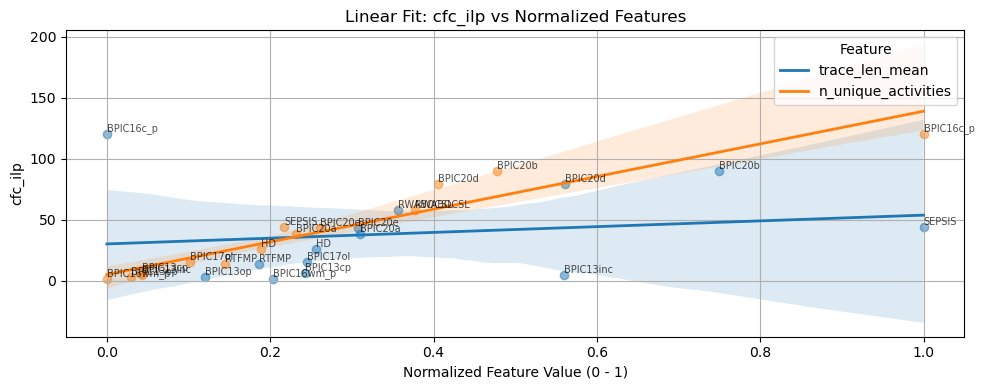

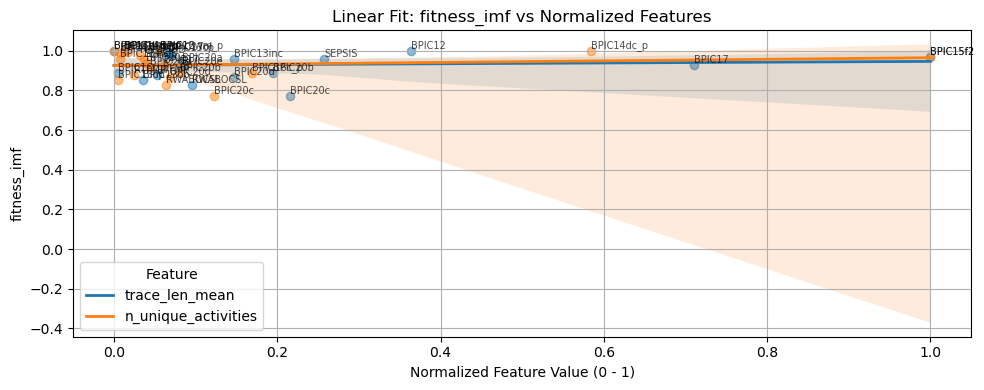

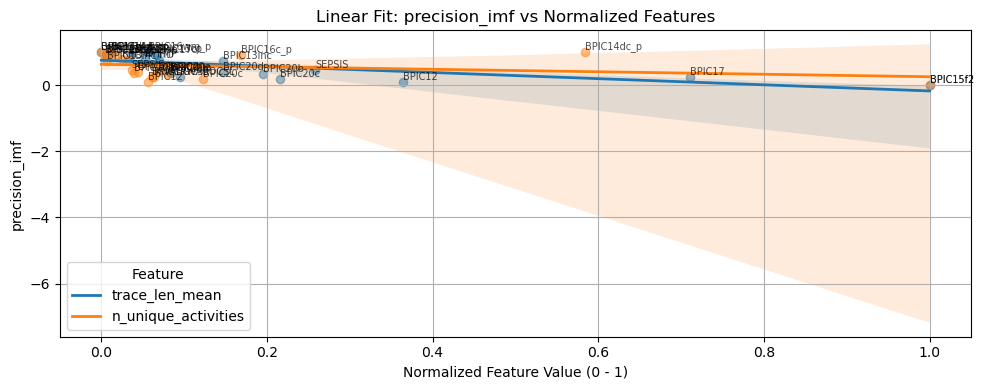

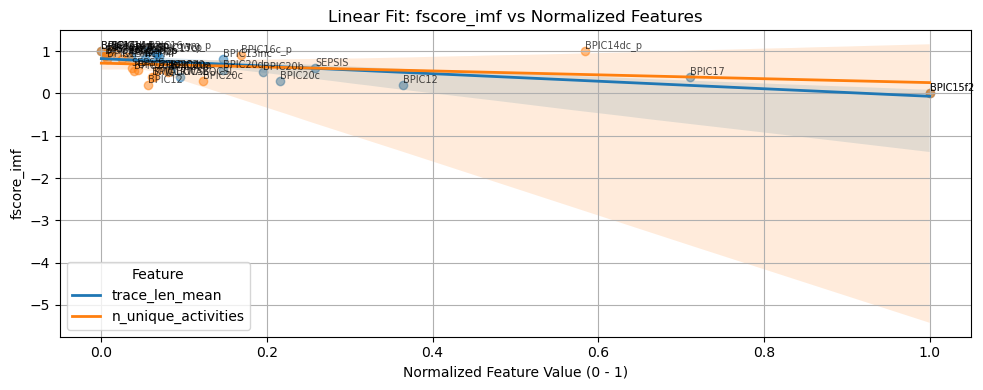

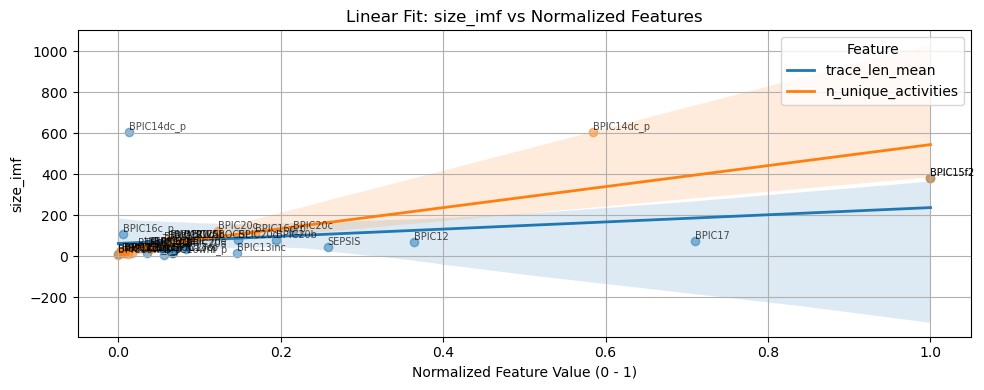

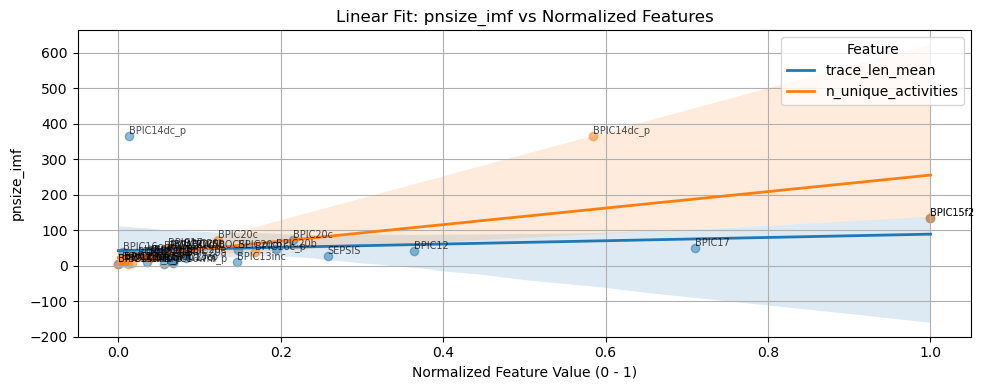

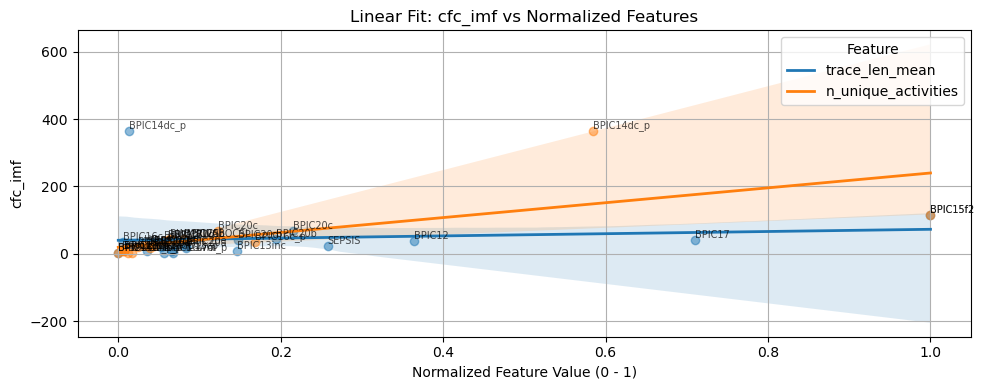

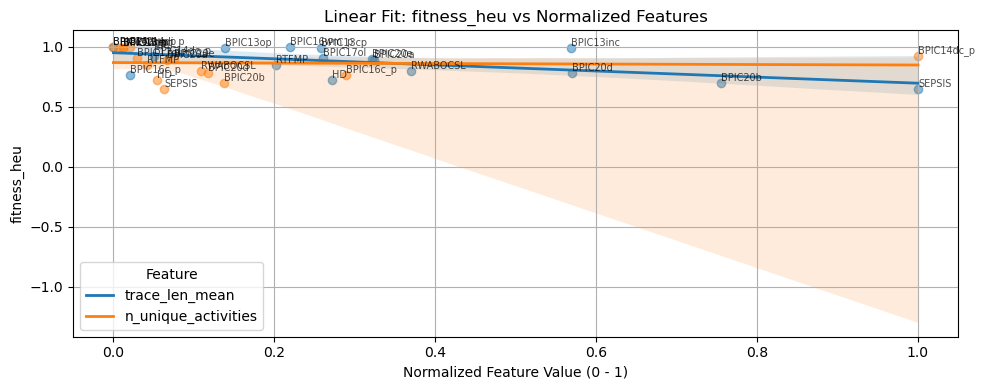

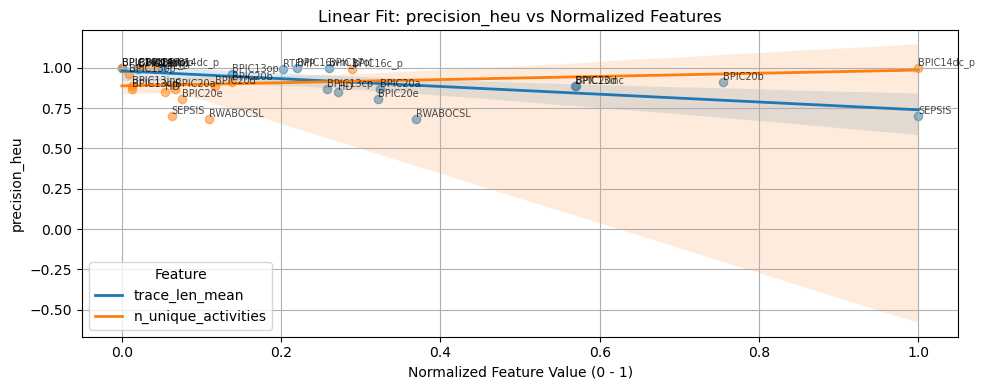

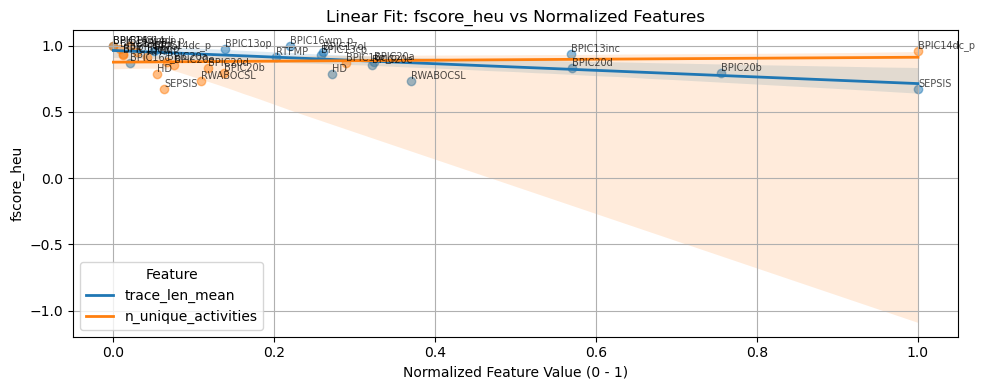

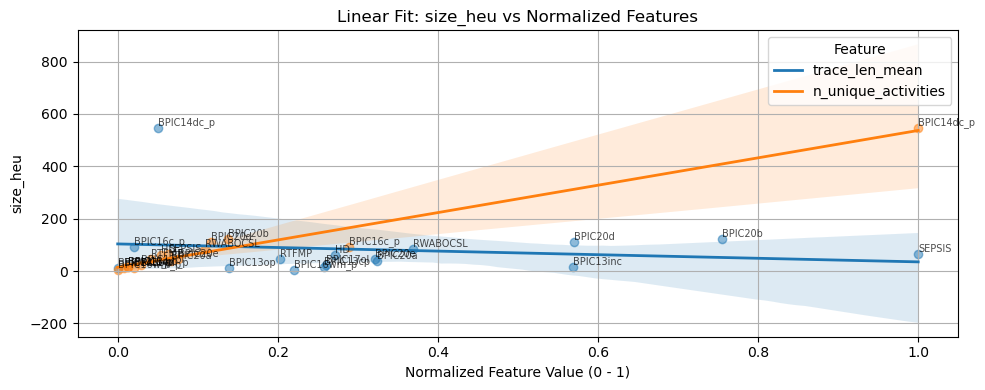

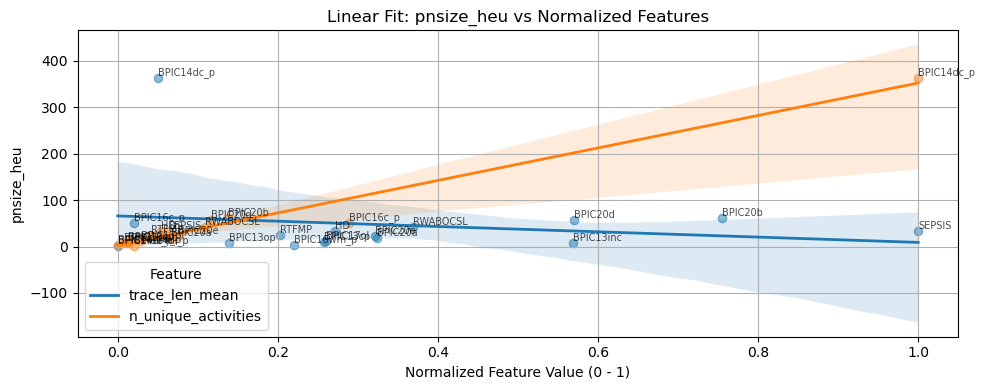

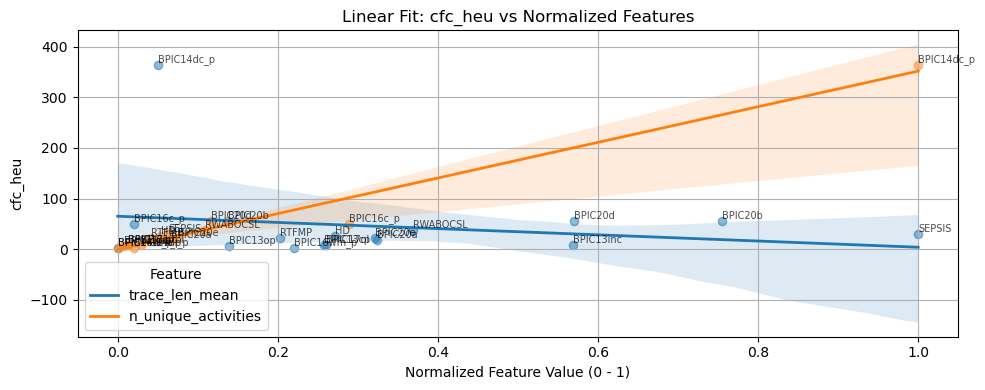

In [34]:
import matplotlib.lines as mlines

for metric in metric_names:
    fig, ax = plt.subplots(figsize=(10, 4))
    
    feat_bench_clean = feat_bench.dropna(subset=feature_names + [metric, 'log'])
    
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(feat_bench_clean[feature_names])
    feat_scaled = pd.DataFrame(X_scaled, columns=feature_names)
    feat_scaled[metric] = feat_bench_clean[metric].values
    feat_scaled['log'] = feat_bench_clean['log'].values

    colors = sns.color_palette("tab10", n_colors=len(feature_names))
    legend_handles = []
    
    for feature, color in zip(feature_names, colors):
        sns.regplot(
            x=feat_scaled[feature],
            y=feat_scaled[metric],
            scatter_kws={'alpha': 0.5, 'color': color},
            line_kws={'color': color, 'linewidth': 2},
            ax=ax
        )
        
        for i in range(len(feat_scaled)):
            x_val = feat_scaled[feature].iloc[i]
            y_val = feat_scaled[metric].iloc[i]
            label = str(feat_scaled['log'].iloc[i])
            
            if np.isfinite(x_val) and np.isfinite(y_val):
                ax.text(
                    x_val,
                    y_val,
                    label,
                    fontsize=7,
                    alpha=0.7,
                    #color=color,
                    ha='left',
                    va='bottom'
                )
        
        # Create a Line2D object for the legend with a thin line matching the regression line
        line_handle = mlines.Line2D([], [], color=color, linewidth=2, label=feature)
        legend_handles.append(line_handle)

    ax.set_xlabel('Normalized Feature Value (0 - 1)')
    ax.set_ylabel(metric)
    ax.set_title(f'Linear Fit: {metric} vs Normalized Features')
    ax.grid(True)
    ax.legend(handles=legend_handles, title='Feature')
    plt.tight_layout()
    plt.show()